# Phase Hunter: quantum phase inference you can play
**Team Popeyes (solo): Tanish Singh Rajpal. Q-SITE 2026 Quantum Coalition Scientific Track.**

We ask three linked questions: how does ring size frustrate a period-four pattern, how does gate noise change inference from correlators, and how should a player spend a finite measurement budget? The browser game exposes the same observables and uncertainty studied here.

This is a classical simulation of quantum states, not a quantum-speedup claim. Clean states are exact; noisy states come from the archived four-layer VQE scan. Its deterministic fits were recovered and checked against every archived energy and mean to obtain missing joint readout statistics. The original noisy expectation values have not been replaced.

## 1. Environment and independent Hamiltonian check
The PennyLane and NumPy implementations use the same periodic ANNNI convention. Compare complete matrices and ground energies at three points before interpreting phase labels.

In [1]:
import json, hashlib
from pathlib import Path
import numpy as np
from src.annni import AnnniChain
from src.pennylane_pipeline import cross_check
from src.measurement import joint_outcomes, joint_moments, sample_joint
from src.fidelity import invariant_basis, subspace_fidelity
ROOT=Path.cwd()
def load(name): return json.loads((ROOT/'data'/name).read_text())
if 'show_figure' not in globals():
    from IPython.display import display, Image
    def show_figure(name): display(Image(filename=str(ROOT/'figures'/name)))
for result in cross_check(8):
    assert result['max_matrix_difference']<1e-12
    print(result)


{'kappa': 0.2, 'h': 0.4, 'max_matrix_difference': 5.329070518200751e-15, 'energy_numpy': -6.816385034791361, 'energy_pennylane': -6.816385034791363}
{'kappa': 0.8, 'h': 0.2, 'max_matrix_difference': 5.329070518200751e-15, 'energy_numpy': -6.502928201402121, 'energy_pennylane': -6.502928201402123}
{'kappa': 0.5, 'h': 1.5, 'max_matrix_difference': 0.0, 'energy_numpy': -13.193520790040754, 'energy_pennylane': -13.193520790040758}


## 2. Model and observable meaning
H = −Σ ZᵢZᵢ₊₁ + κΣ ZᵢZᵢ₊₂ − hΣ Xᵢ on a periodic ring. Nearest neighbors favor agreement; κ favors disagreement at distance two; h competes with both. C1 and C2 average pair products over all sites. Large positive C1 signals ferromagnetic order, negative C2 signals the ++-- stripe, and small correlations signal disorder.

In [2]:
chain=AnnniChain(8)
for k,h in [(.2,.1),(.8,.1),(.3,1.8)]:
    state,energy=chain.ground_state(k,h)
    print(f'kappa={k}, h={h}, energy={energy:.6f}',chain.measure(state))


kappa=0.2, h=0.1, energy=-6.425052 {'zz1': 0.9960631772677779, 'zz2': 0.9960387178722764, 'sd1': 0.04429193229834338, 'sd2': 0.04470258233733597}
kappa=0.8, h=0.1, energy=-6.425179 {'zz1': 1.3801886514340272e-05, 'zz2': -0.9959922019720224, 'sd1': 0.0027655437717683654, 'sd2': 0.044845304646777544}
kappa=0.3, h=1.8, energy=-15.391088 {'zz1': 0.22640613351281758, 'zz2': 0.0013011853212340453, 'sd1': 0.3258998176593735, 'sd2': 0.36293073235984813}


## 3. Clean phase map
Three seeded k-means clusters use (C1,C2); seeds lie in known phase interiors. The analytic reference is qualitative at finite N. Floating-reference cells are excluded from the primary score because the classifier does not independently resolve that phase. The 40×40 headline grid should not be confused with the 24×24 game grid.

{
  "backend": "pennylane",
  "qubits": 8,
  "grid": [
    40,
    40
  ],
  "ground_states": 1600,
  "seconds": 54.81,
  "accuracy_excluding_floating": 0.9228,
  "accuracy_all_cells": 0.8894,
  "floating_cell_fraction": 0.0362
}


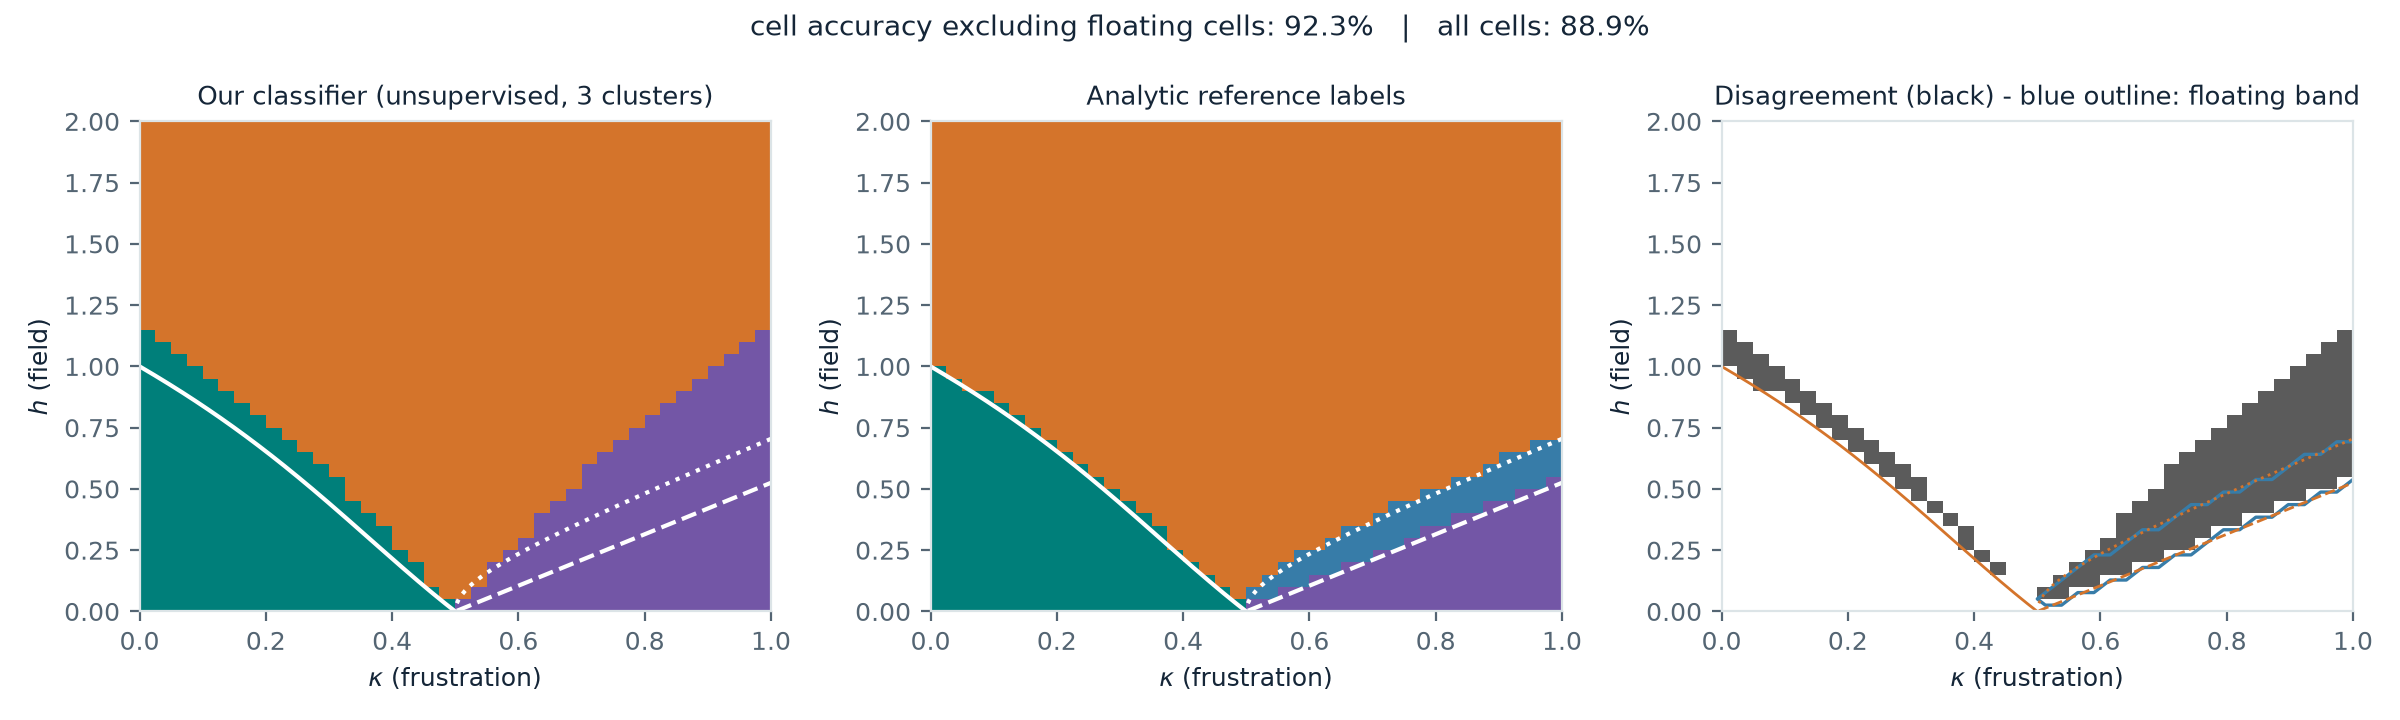

In [3]:
summary=load('summary.json')
print(json.dumps(summary,indent=2))
show_figure('clean_phase_diagram.png')


### The raw signal beneath the labels
Classification can hide attenuation and ambiguity. These maps show the observables before clustering; downstream threshold decisions depend on their scale.

zz1 range: 0.0 1.0
zz2 range: -1.0 1.0


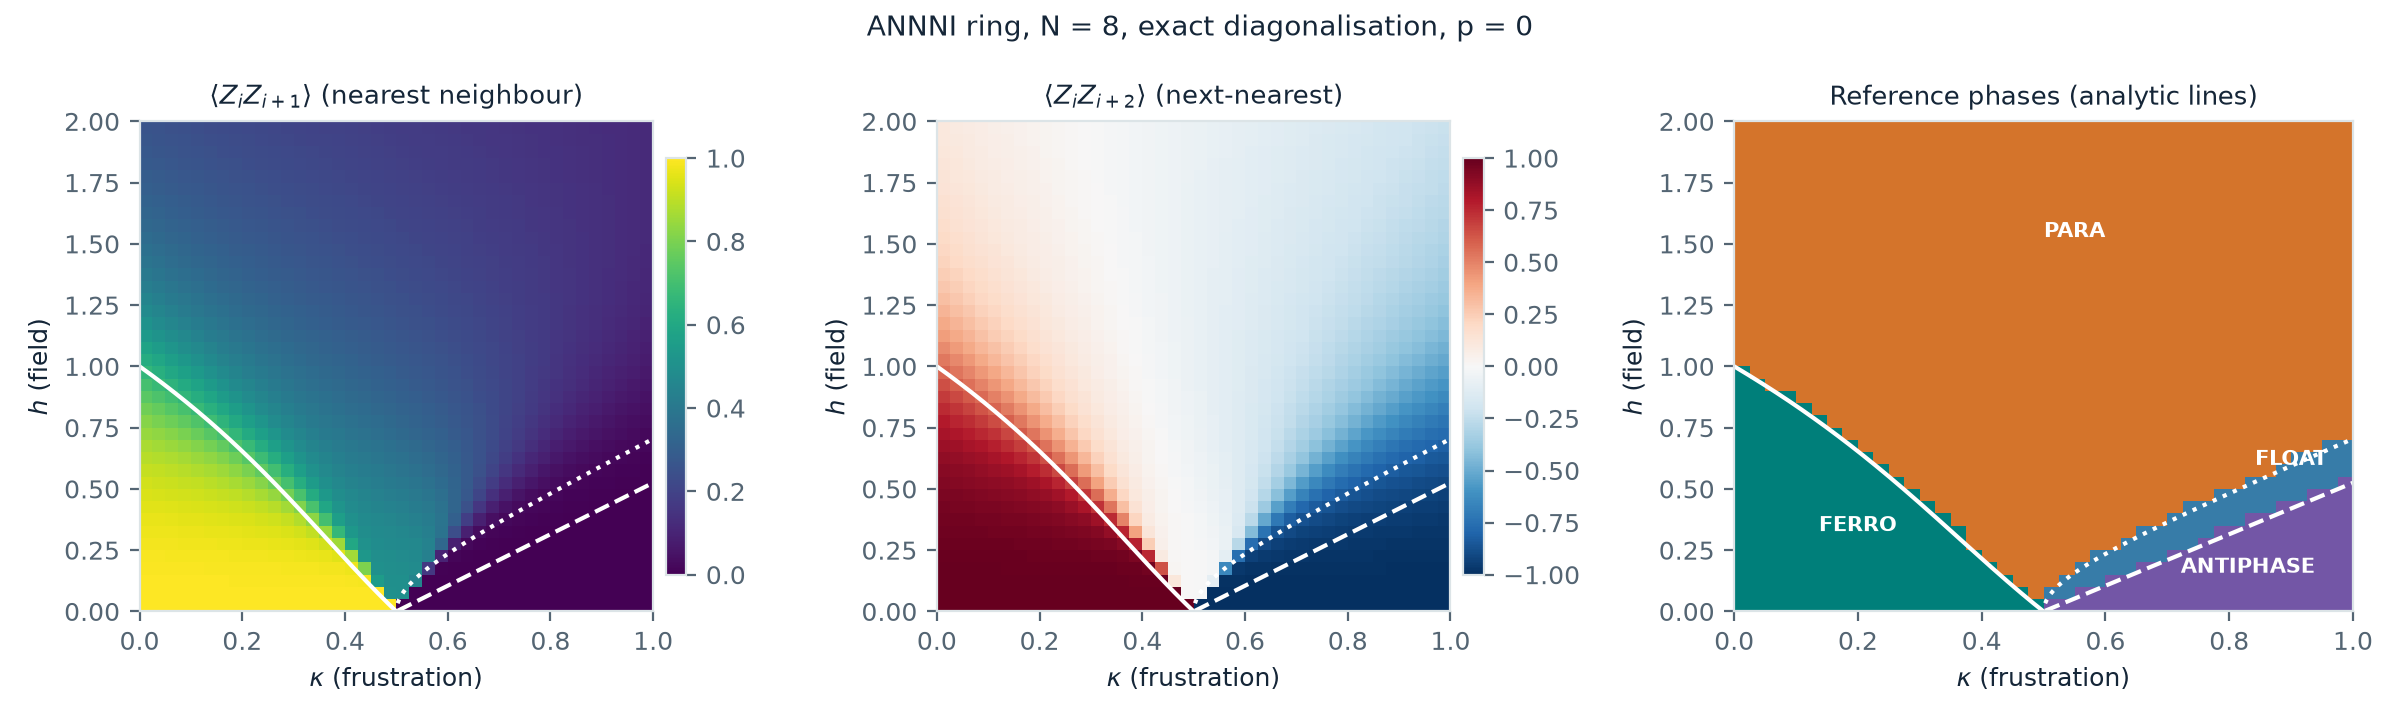

In [4]:
show_figure('clean_correlators.png')
grid=np.load(ROOT/'data/grid_N8.npz')
for key in ['zz1','zz2']:
    print(key,'range:',float(grid[key].min()),float(grid[key].max()))


## 4. Commensuration: why a six-spin ring is a bad stripe benchmark
A perfect ++-- pattern closes only when N is divisible by four. At κ=0.8, h=0.1, N=6 gives C2≈−0.332, while N=8 and N=12 give about −0.996. On the same 24×24 grid, classification agrees with the non-floating reference on 43.9%, 91.9%, and 95.1% respectively. This is finite-size frustration and classifier sensitivity, not disappearance of the thermodynamic antiphase.

Same interior point: 0.8 0.1
N= 6: C2=-0.331966, agreement=43.86%
N= 8: C2=-0.995992, agreement=91.88%
N=12: C2=-0.996050, agreement=95.13%


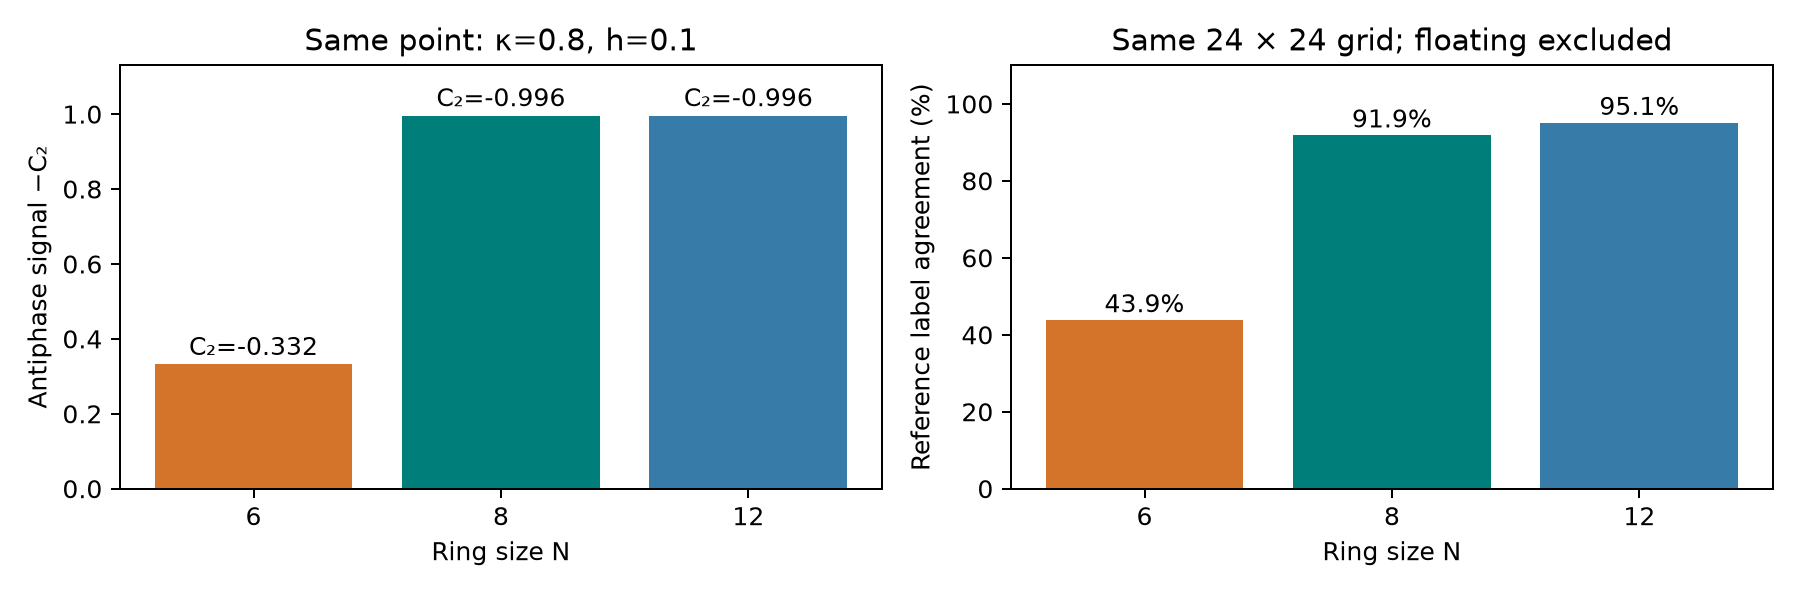

In [5]:
size=load('commensuration.json')
print('Same interior point:',size['kappa'],size['h'])
for row in size['rows']:
    print(f"N={row['qubits']:2}: C2={row['zz2']:.6f}, agreement={100*row['agreement_excluding_floating']:.2f}%")
show_figure('commensuration.png')


### A bound independent of the ground-state solver
Enumerate Z-basis bitstrings. The minimum possible C2 is −1/3 on N=6 and −1 on N=8 or 12. Every quantum Z-readout expectation is a convex average of those values, so no state on the six-spin ring can evade the bound.

In [6]:
for n in [6,8,12]:
    values,_=joint_outcomes(n)
    minimum=values[:,1].min()
    np.testing.assert_allclose(minimum,-1/3 if n==6 else -1,atol=1e-14)
    print('N =',n,'minimum C2 =',minimum)


N = 6 minimum C2 = -0.3333333333333333
N = 8 minimum C2 = -1.0
N = 12 minimum C2 = -1.0


## 5. Noisy state preparation and remaining fit error
At each point a four-layer RY/RZ+CNOT-ring ansatz is fitted on default.qubit. The same parameters are evaluated on default.mixed at p=0,0.01,0.05, with target depolarization immediately after each CNOT. Sharing parameters separates channel effects from remaining VQE preparation error within a point. It does not turn an imperfect VQE state into an exact ground state.

In [7]:
noise=load('noise_analysis.json')
print(json.dumps(noise['vqe_quality'],indent=2))
scan=np.load(ROOT/'data/pennylane_scan_N8.npz')
error=np.abs(scan['energy_vqe']-scan['energy_exact'])
print('Independently recomputed energy error:',error.mean(),error.max())
assert np.isclose(error.mean(),noise['vqe_quality']['energy_error_mean'])


{
  "energy_error_mean": 0.1494333541067532,
  "energy_error_max": 0.3226461865024284,
  "energy_error_relative_mean": 0.014781798509985214,
  "zz1_vs_exact_mean_abs": 0.02712546240701852,
  "zz2_vs_exact_mean_abs": 0.04215723044680804,
  "points_above_0_05": 443,
  "refit_fraction": 0.7829861111111112
}
Independently recomputed energy error: 0.1494333541067532 0.3226461865024284


### Fixed versus recalibrated inference
The fixed clean rule calls about 39% less area ordered at p=0.05. Recalibration recovers most area, with small boundary changes. This is not evidence that physical transitions cannot move under noise. The antiphase and ferromagnetic interiors lose about 47% and 40% of their signals; the N=12 cuts reproduce the ordering (0.512 vs 0.615). Likely mechanism: the antiphase lives on the distance-2 correlator, with more gates between the compared spins, so the same per-gate error costs it more. Both sizes agree with this handout prediction, but isolating distance would need a third distance or a depth sweep.

0.0 ordered area: fixed 0.3263888888888889 refitted 0.3263888888888889
0.01 ordered area: fixed 0.3246527777777778 refitted 0.3263888888888889
0.05 ordered area: fixed 0.1996527777777778 refitted 0.3315972222222222
Cut near kappa=.30: {'phase': 'ferro', 'analytic_boundary': 0.43215826548129316, 'fixed_p0.0': 0.43478260869565216, 'fixed_p0.01': 0.43478260869565216, 'fixed_p0.05': 0.17391304347826086, 'recal_p0.0': 0.43478260869565216, 'recal_p0.01': 0.43478260869565216, 'recal_p0.05': 0.5217391304347826}


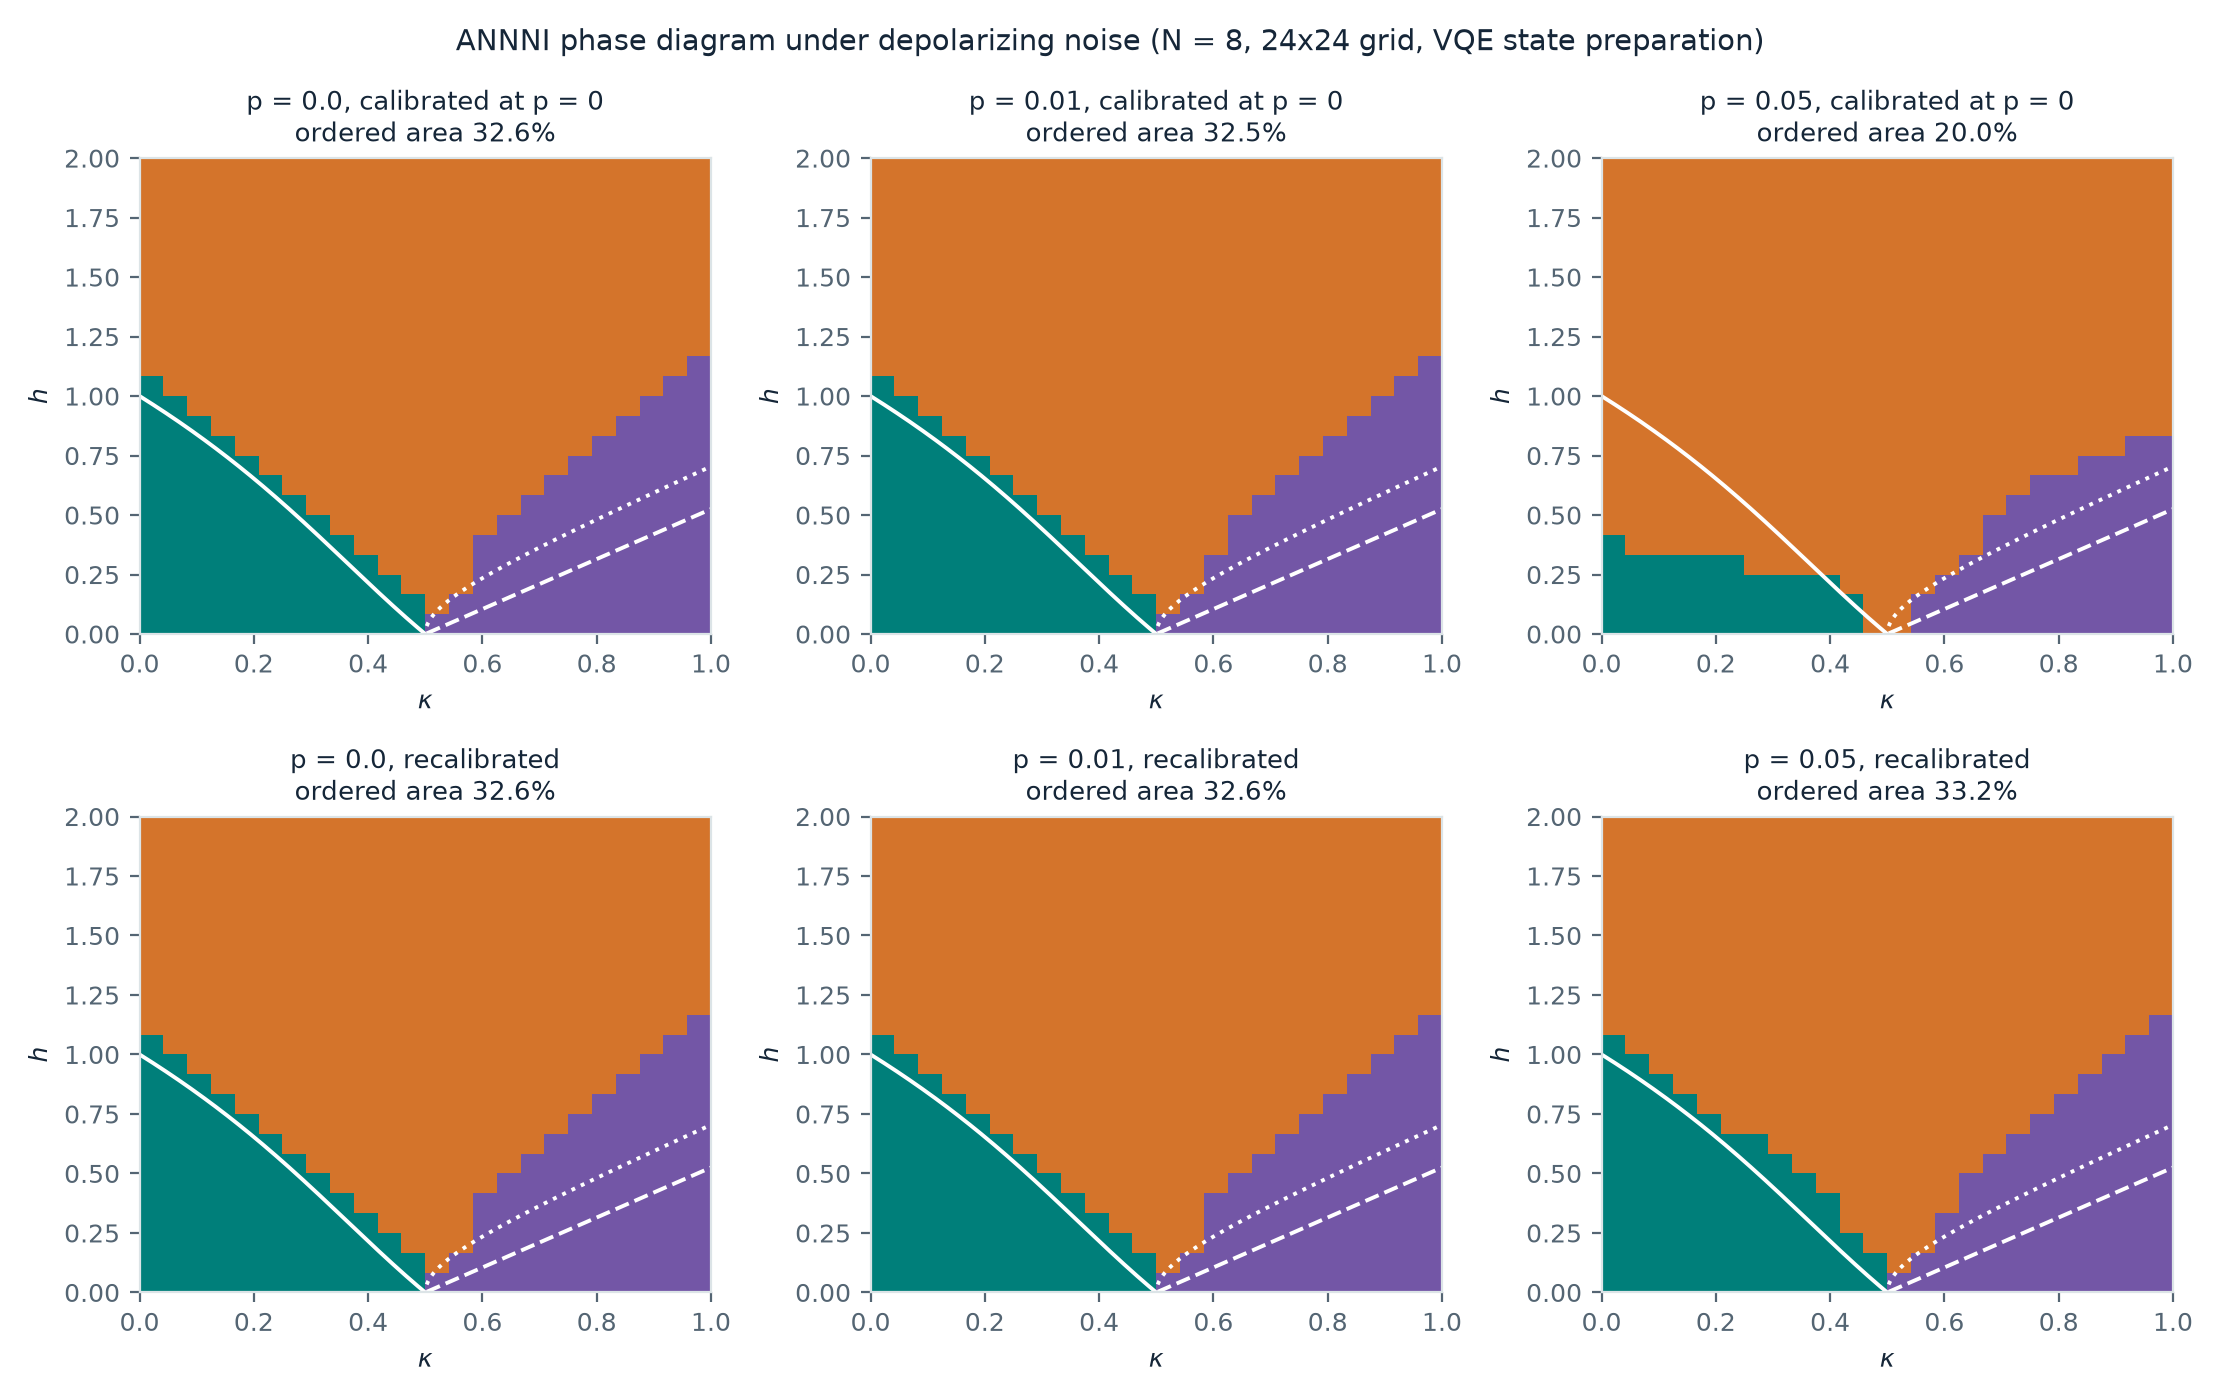

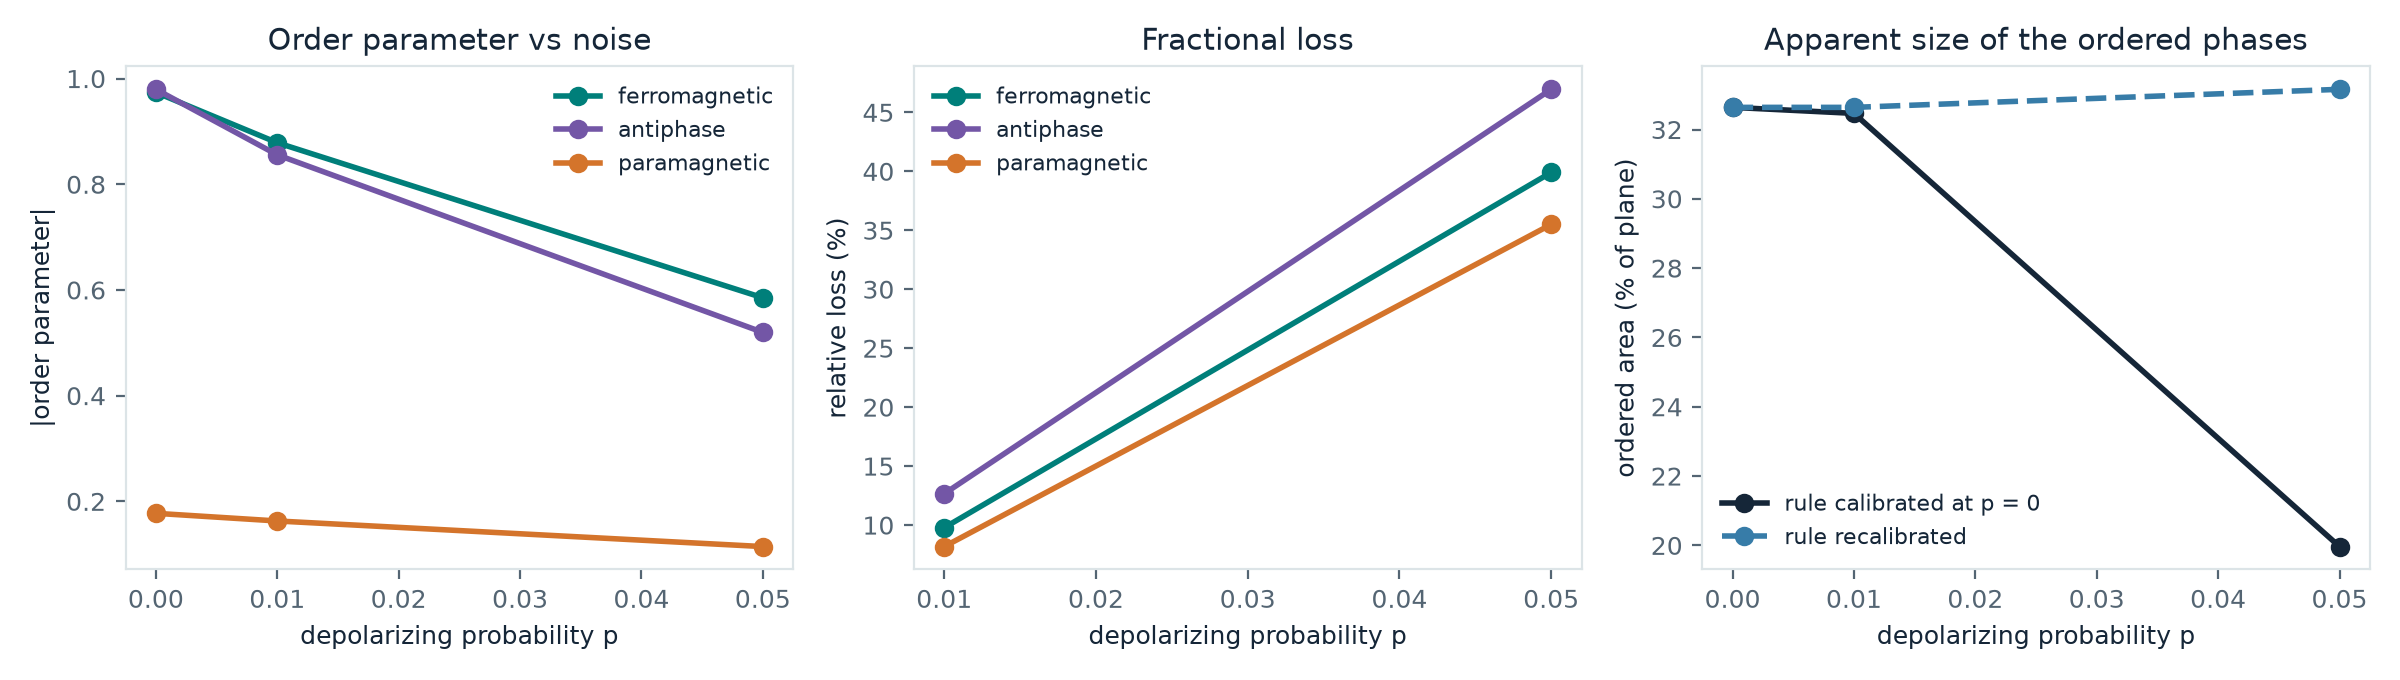

In [8]:
for p,row in noise['phase_areas'].items():
    print(p,'ordered area: fixed',row['fixed_rule']['ordered'],'refitted',row['recalibrated']['ordered'])
print('Cut near kappa=.30:',noise['boundary_cuts']['kappa=0.30'])
show_figure('phase_diagrams_noise.png')
show_figure('noise_analysis.png')


### Clean → noisy → recalibrated
These maps use identical axes and colours. The clean baseline is the same prepared circuit at p=0. Recalibration changes inferred labels, not the quantum state; it cannot restore lost quantum information.

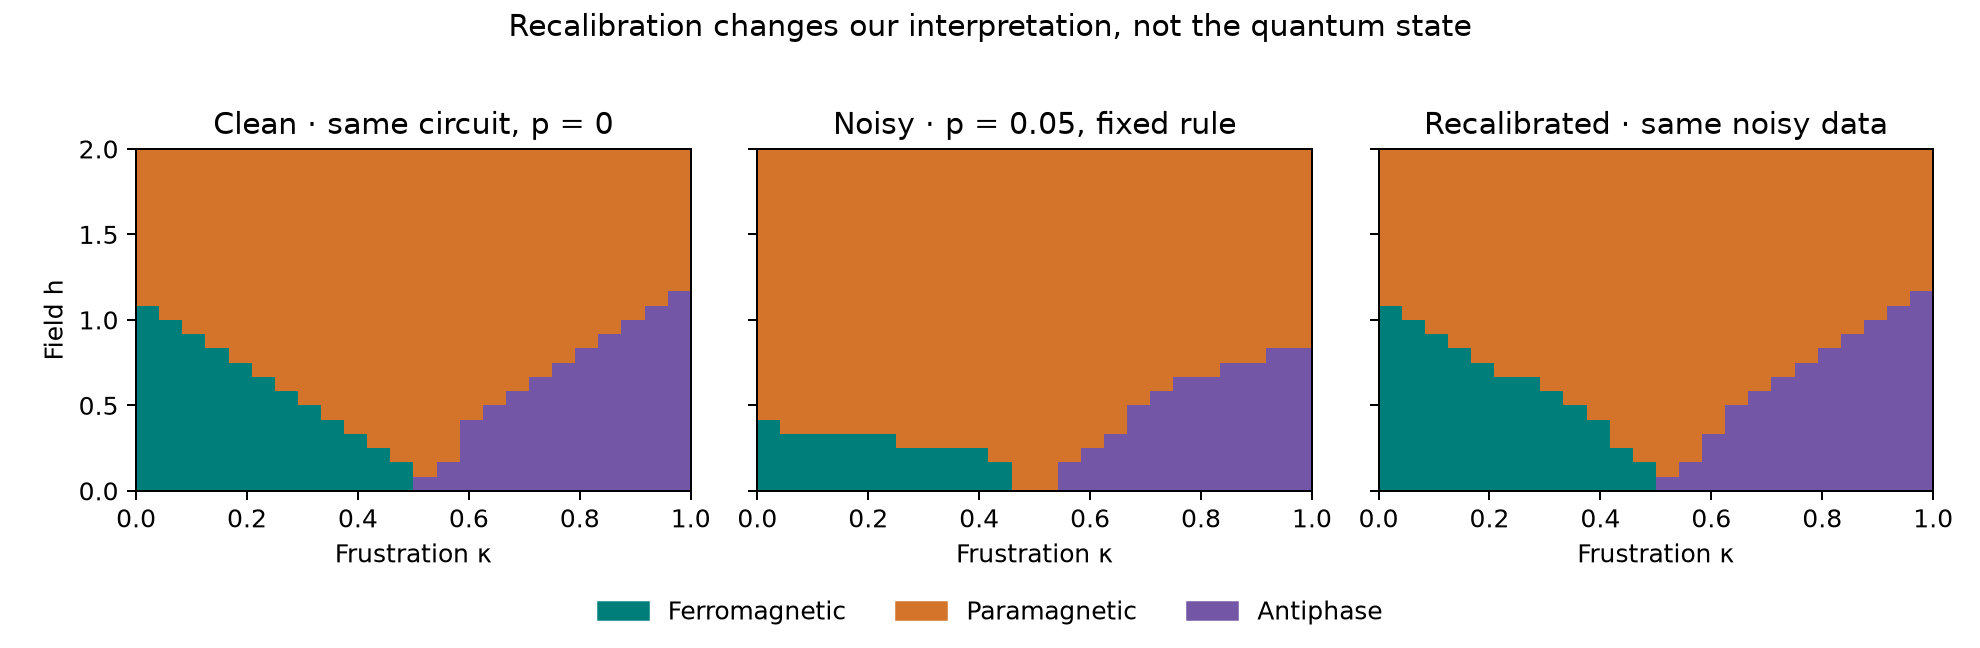

In [9]:
show_figure('noise_comparison.png')


### Finite-shot recalibration: a paired test
At each point, sample 20, 100 or 500 joint whole-register outcomes. Both classifiers receive exactly the same noisy observations. The fixed rule uses precomputed noiseless centroids; the recalibrated rule fits the observed map without target labels or extra shots. We repeat at 1% and 5% noise for 200 seeds and score against the same prepared circuit's noiseless labels, excluding reference floating cells.

This tests transductive inference on the full measured map, not calibration transfer to an unseen map, exact-ground-state recovery, or zero-noise extrapolation. Each run costs shots-per-point × 576, so it is not the sparse-ping budget experiment.

p=0.01, 20 shots/point: fixed 98.53%, recalibrated 97.64%; gain -0.88 pp, SE 0.036 pp
p=0.01, 100 shots/point: fixed 99.53%, recalibrated 99.20%; gain -0.33 pp, SE 0.027 pp
p=0.01, 500 shots/point: fixed 99.75%, recalibrated 99.80%; gain +0.05 pp, SE 0.017 pp
p=0.05, 20 shots/point: fixed 85.38%, recalibrated 93.74%; gain +8.36 pp, SE 0.102 pp
p=0.05, 100 shots/point: fixed 85.35%, recalibrated 97.77%; gain +12.42 pp, SE 0.074 pp
p=0.05, 500 shots/point: fixed 85.73%, recalibrated 98.60%; gain +12.87 pp, SE 0.055 pp
At 5% noise recalibration helps even at 20 shots; at 1% it slightly hurts at 20/100 shots. More flexible fitting is not automatically better.


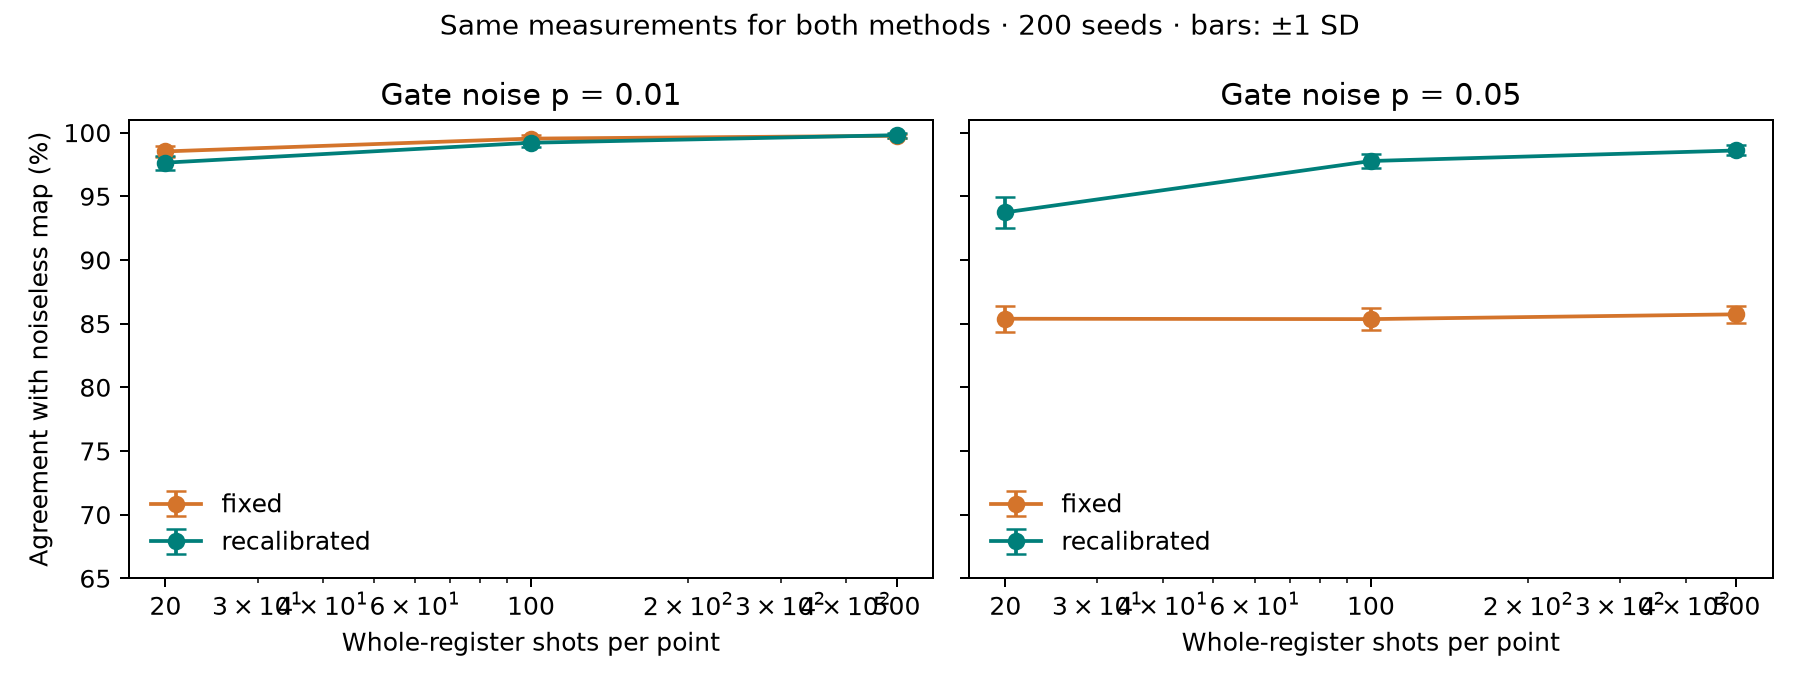

In [10]:
finite=load('finite_shot_recalibration.json')
assert finite['seeds']==200
for p,rows in finite['noise'].items():
    for shots,row in rows.items():
        assert row['total_shots']==int(shots)*576
        assert np.isclose(row['paired_gain']['mean'],row['recalibrated']['mean']-row['fixed']['mean'])
        print(f"p={p}, {shots} shots/point: fixed {row['fixed']['mean']:.2%}, recalibrated {row['recalibrated']['mean']:.2%}; gain {100*row['paired_gain']['mean']:+.2f} pp, SE {100*row['paired_gain']['standard_error']:.3f} pp")
show_figure('finite_shot_recalibration.png')
print('At 5% noise recalibration helps even at 20 shots; at 1% it slightly hurts at 20/100 shots. More flexible fitting is not automatically better.')


## 6. What a shot actually measures
Both observables are diagonal in Z. One register readout supplies both site-averaged correlators. All shots contribute to both estimates, with covariance retained. Bitstrings with identical (C1,C2) are grouped losslessly into joint categories. Draw multinomial counts over these categories, not two independent binomials and not an unbounded Gaussian.

The noisy archive originally held only means. Recovered VQE parameters and qml.probs distributions are verified against every saved energy and mean; clean-state widths are not substituted for noisy widths.

In [11]:
readout=np.load(ROOT/'data/readout_N8.npz')
validation=load('readout_validation.json')
assert validation['archive_sha256']==hashlib.sha256((ROOT/'data/pennylane_scan_N8.npz').read_bytes()).hexdigest()
print(json.dumps(validation,indent=2))
for j,p in enumerate(readout['noise']):
    means=readout['readout'][j]@readout['outcomes']
    for d in [1,2]:np.testing.assert_allclose(means[:,:,d-1],scan[f'p{p}_zz{d}'],atol=1e-7,rtol=0)
print('Every recovered noisy mean agrees with its archive.')


{
  "protocol": "whole-register Z; joint site-averaged C1/C2 outcomes",
  "archive_sha256": "cb133966a3bcc86e939603b97ebe2ea0ee4dd1ca6bd4121cf7633e3669ffd3f8",
  "grid": [
    24,
    24
  ],
  "max_recovery_difference": 1.1538547894929252e-12,
  "cold_steps": 150,
  "warm_steps": 60,
  "layers": 4,
  "seed": 0,
  "minutes": 19.019670967260996
}
Every recovered noisy mean agrees with its archive.


### Sampling means, bounds, variances and covariance
For a shot outcome vector X, the ping mean has covariance Cov(X)/shots. Both correlators share the same category counts. The following Monte Carlo check compares all entries of the covariance matrix, not only marginal error bars.

In [12]:
state,_=chain.ground_state(.3,.7)
outcomes,inverse=joint_outcomes(8)
probabilities=np.bincount(inverse,weights=np.abs(state)**2,minlength=len(outcomes))
means,cov=joint_moments(probabilities,outcomes)
rng=np.random.default_rng(74)
draws=np.array([sample_joint(probabilities,outcomes,100,rng) for _ in range(20000)])
np.testing.assert_allclose(draws.mean(axis=0),means,atol=.002)
np.testing.assert_allclose(np.cov(draws.T),cov/100,atol=.00015)
assert np.all(np.abs(draws)<=1)
print('Mean:',means,'empirical:',draws.mean(axis=0))
print('Predicted ping covariance:',cov/100)
print('Empirical ping covariance:',np.cov(draws.T))


Mean: [0.47142899 0.17918369] empirical: [0.47149525 0.17923375]
Predicted ping covariance: [[0.00086361 0.00089463]
 [0.00089463 0.00170567]]
Empirical ping covariance: [[0.00085375 0.00087881]
 [0.00087881 0.0016831 ]]


### Why splitting the shots changed the result
An alternative protocol measures one random pair per preparation and allocates half the shots to each distance. It is physically valid but discards simultaneous measurements and spatial averaging. Its marginal variances are (1−C²)/(shots/2). Compare those against full-register variances for the same state; do not assume N independent sites inside an entangled register.

In [13]:
pair_variance=(1-means**2)/50
register_variance=np.diag(cov)/100
print('Random-pair split-shot variance:',pair_variance)
print('Whole-register variance:',register_variance)
print('Variance ratio at this one point:',pair_variance/register_variance)
print('This pointwise ratio is not a universal strategy speedup.')


Random-pair split-shot variance: [0.01555509 0.01935786]
Whole-register variance: [0.00086361 0.00170567]
Variance ratio at this one point: [18.01177663 11.34912269]
This pointwise ratio is not a universal strategy speedup.


## 7. Equal-cost strategy comparison
All four strategies receive exactly 6,10,16,24,36 or 50 pings at 100 whole-register shots each. Grid fills every stated budget, and bisection distributes remainder pings across columns. Adaptive starts with coarse coverage and samples near its estimated edge. A fixed max(C1,−C2)>0.46 rule produces votes; three-nearest weighted voting reconstructs the map. Scoring uses stage clusters and excludes the analytic floating band. There are 200 seeds per strategy/stage/budget.

{
  "shots_per_ping": 100,
  "seeds": 200,
  "sampling": "whole-register Z; joint multinomial; both correlators use all shots",
  "budget": "exact same ping count for all methods",
  "scoring": "stage cluster labels, reference floating cells excluded",
  "threshold": 0.46
}
Clear skies {'random': 86.08, 'grid': 86.46, 'bisect': 86.85, 'adaptive': 89.89}
Static {'random': 86.74, 'grid': 90.28, 'bisect': 89.5, 'adaptive': 91.28}
Whiteout {'random': 84.07, 'grid': 89.08, 'bisect': 84.76, 'adaptive': 89.18}


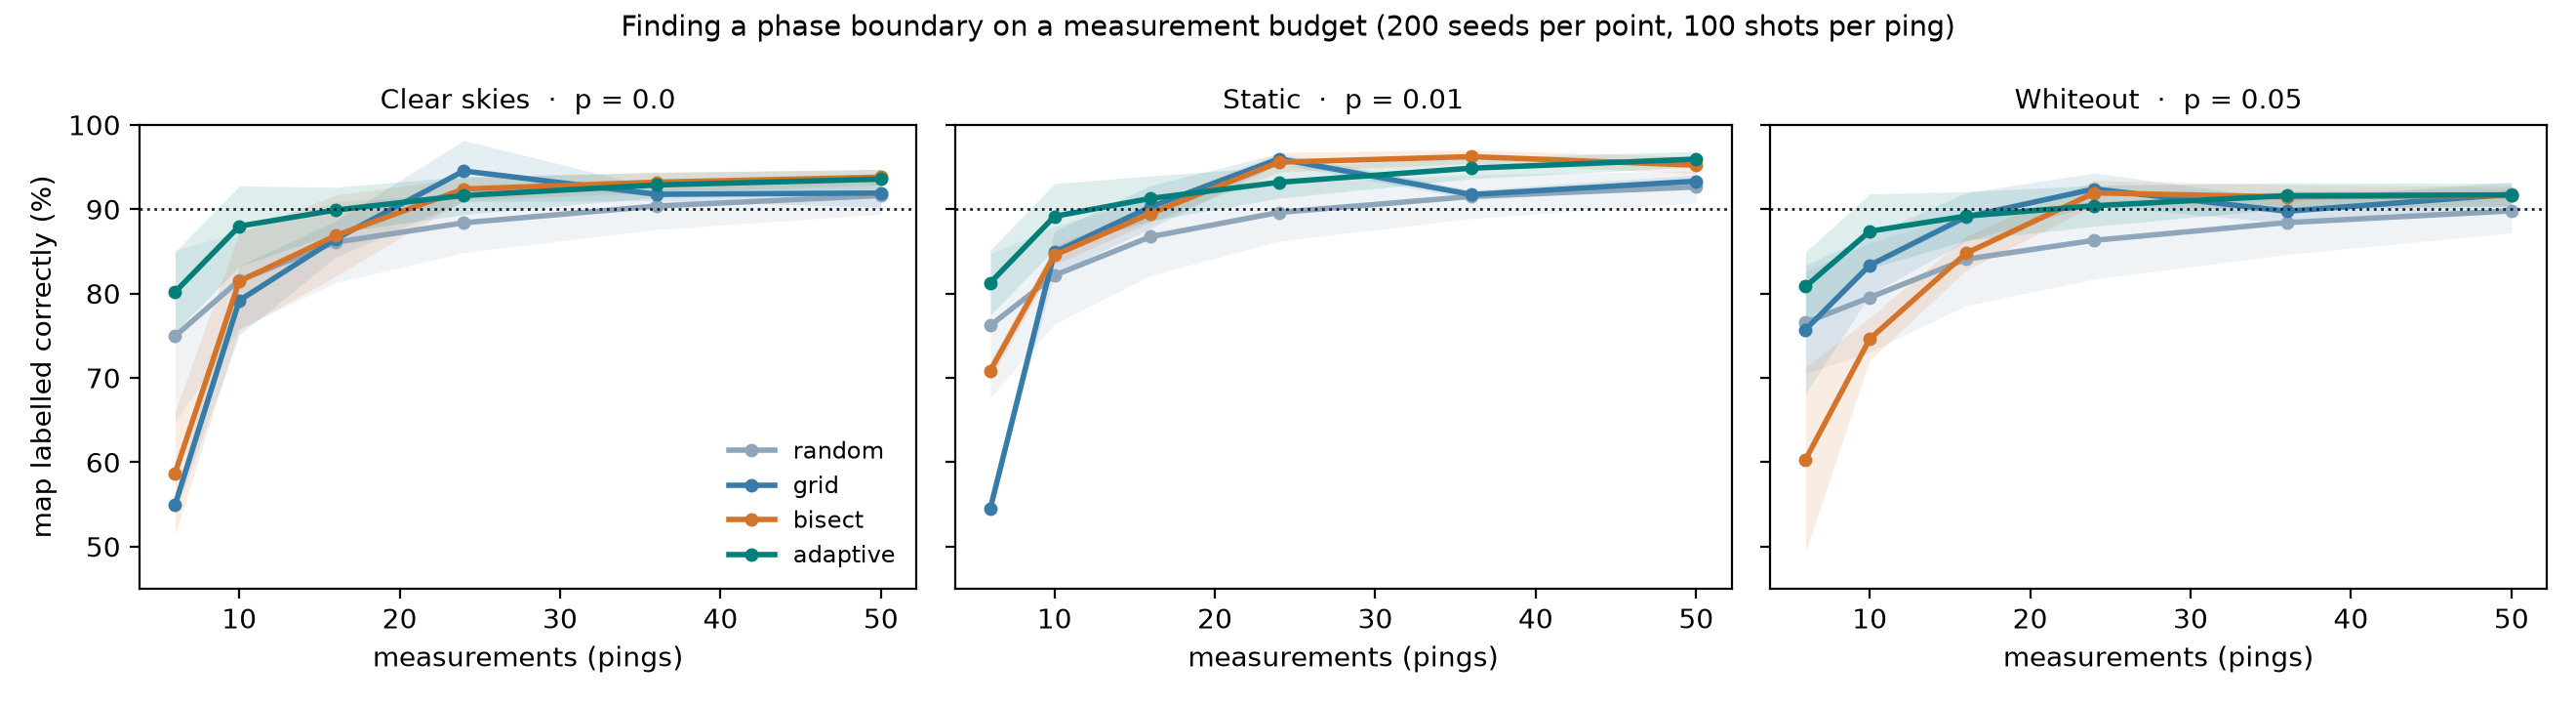

In [14]:
budget=load('budget_study.json')
assert budget['protocol']['seeds']==200
print(json.dumps(budget['protocol'],indent=2))
for stage in ['Clear skies','Static','Whiteout']:
    print(stage,{m:round(100*budget[stage][m]['16']['mean'],2) for m in ['random','grid','bisect','adaptive']})
show_figure('budget_study.png')


### First tested 90% crossings and uncertainty
The budget ladder is coarse. Report the first tested crossing without interpolation and flag any tested mean within two standard errors of 90%. Standard errors quantify uncertainty in a mean across seeds; the plot's shaded standard deviation describes run-to-run variability. Two-SE flags are approximate screening criteria, not simultaneous confidence guarantees across all comparisons.

In [15]:
print('First tested 90% crossings:',json.dumps(budget['pings_to_reach_90pct'],indent=2))
print('Borderline means:',json.dumps(budget['borderline_crossings'],indent=2))
for stage in ['Clear skies','Static','Whiteout']:
    for strategy,rows in budget[stage].items():
        for b,row in rows.items():
            assert abs(row['standard_error']-row['sd']/np.sqrt(200))<1e-6
print('Standard-error checks passed. Cross-stage differences also include preparation and classifier changes.')


First tested 90% crossings: {
  "Clear skies": {
    "random": 36,
    "grid": 24,
    "bisect": 24,
    "adaptive": 24
  },
  "Static": {
    "random": 36,
    "grid": 16,
    "bisect": 24,
    "adaptive": 16
  },
  "Whiteout": {
    "random": null,
    "grid": 24,
    "bisect": 24,
    "adaptive": 24
  }
}
Borderline means: [
  {
    "stage": "Clear skies",
    "strategy": "random",
    "budget": 36,
    "mean": 0.9037,
    "standard_error": 0.001963,
    "first_crossing": true
  },
  {
    "stage": "Clear skies",
    "strategy": "adaptive",
    "budget": 16,
    "mean": 0.898944,
    "standard_error": 0.001912,
    "first_crossing": false
  },
  {
    "stage": "Static",
    "strategy": "random",
    "budget": 24,
    "mean": 0.8962,
    "standard_error": 0.002408,
    "first_crossing": false
  },
  {
    "stage": "Static",
    "strategy": "grid",
    "budget": 16,
    "mean": 0.902753,
    "standard_error": 0.001796,
    "first_crossing": true
  },
  {
    "stage": "Whiteout",
    "

## 8. Independent fidelity diagnostic
For positive h the unique positive ground state lies in the translation-invariant, global-spin-flip-even sector. Working in this fixed sector avoids arbitrary near-degenerate symmetry partners; h=0 is excluded from finite-difference stencils. The diagnostic uses no cluster labels. The retained general subspace utility also uses the full rectangular overlap without truncating arbitrary basis columns.

In [16]:
basis=invariant_basis(8)
for k,h in [(0,.05),(.3,.4),(.8,.2),(1,2)]:
    matrix=chain.hamiltonian(k,h)
    np.testing.assert_allclose(np.linalg.eigvalsh(basis.T@matrix@basis)[0],np.linalg.eigvalsh(matrix)[0],atol=1e-10)
lo=np.eye(4)[:,:2];hi=np.eye(4)[:,1:2];rotation=np.array([[.6,-.8],[.8,.6]])
assert abs(subspace_fidelity(lo,hi)-subspace_fidelity(lo@rotation,hi))<1e-12
print('Sector ground energies and basis-invariance checks passed.')


Sector ground energies and basis-invariance checks passed.


### Agreement and disagreement between methods
Fidelity peaks differ from the analytic reference by mean |Δh|≈0.046 at spacing 0.051. Their mean gap from clustering is ≈0.128. Agreement with one reference does not make the two methods interchangeable.

{
  "mean_abs_deviation_from_analytic": 0.045589152445551125,
  "median_abs_deviation_from_analytic": 0.02804242769054726,
  "mean_abs_deviation_kappa_below_0.85": 0.046820809455626125,
  "mean_abs_deviation_kappa_above_0.85": 0.035735896364951086,
  "mean_abs_gap_to_clustering": 0.1282051282051282,
  "grid_spacing_in_h": 0.05128205128205128,
  "method": "unique ground state in translation-invariant, spin-flip-even sector; h=0 excluded",
  "h_zero_excluded": true
}


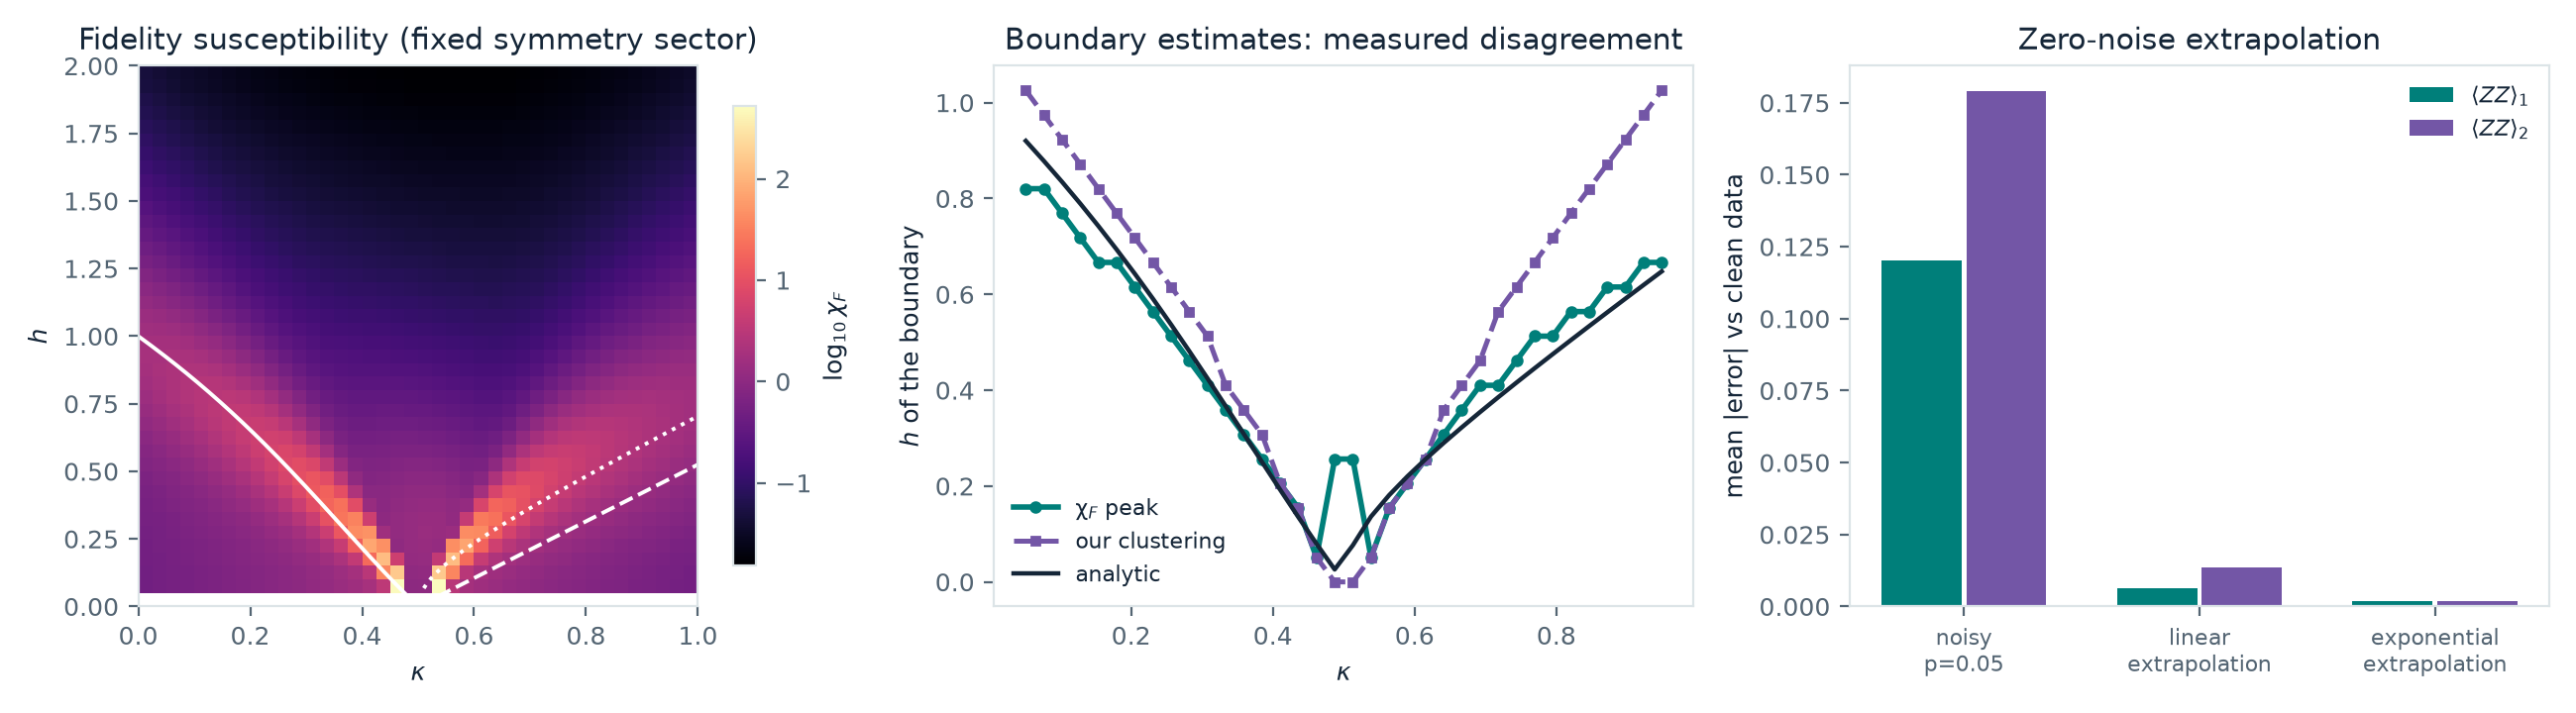

In [17]:
second=load('second_method.json')
print(json.dumps(second['fidelity_susceptibility'],indent=2))
show_figure('second_method.png')


## 9. Zero-noise extrapolation: define the target
Linear and exponential two-point fits use p=0.01 and p=0.05 expectations. Errors are measured against the same variational state at p=0, not an exact ground state. The study uses infinite-shot expectations and known channel strengths; finite-shot error amplification remains untested.

In [18]:
print(json.dumps(second['zero_noise_extrapolation'],indent=2))


{
  "mean_abs_error_before": {
    "zz1": 0.12021411742521576,
    "zz2": 0.17889511366672822
  },
  "mean_abs_error_after": {
    "zz1": {
      "linear": 0.006462487436022318,
      "exponential": 0.0019153713281544913
    },
    "zz2": {
      "linear": 0.013694829028396952,
      "exponential": 0.0020066607178409975
    }
  },
  "phase_areas_under_the_clean_rule": {
    "clean": {
      "ordered_area": 0.3263888888888889,
      "agreement": 0.9223826714801444
    },
    "noisy p=0.05": {
      "ordered_area": 0.1996527777777778,
      "agreement": 0.8953068592057761
    },
    "mitigated (linear)": {
      "ordered_area": 0.3263888888888889,
      "agreement": 0.9223826714801444
    },
    "mitigated (exponential)": {
      "ordered_area": 0.3263888888888889,
      "agreement": 0.9223826714801444
    }
  }
}


## 10. Larger-system noisy check: N=12
Two nine-point cuts span h=0.1…1.3 at κ=0.2 and κ=0.8. The same four-layer ansatz and target depolarizing channels test whether attenuation and classifier-threshold sensitivity persist at larger N. Exact energies provide a preparation-error check. This is a sparse-cut extension, not a full N=12 noisy phase diagram.

Preparation error: {'mean': 0.18550959461360764, 'max': 0.47355036903313596}
{
  "ferromagnet to paramagnet": {
    "kappa": 0.2,
    "order_parameter": "zz1",
    "analytic_boundary": 0.6533598938636982,
    "crossing_clean": 0.8449543583282638,
    "noise": {
      "p0.01": {
        "attenuation_factor": 0.9042489147612575,
        "mean_residual_after_rescaling": 0.0034944789540284843,
        "crossing_fixed_threshold": 0.8256629565344875,
        "crossing_rescaled_threshold": 0.8482651447043379,
        "shift_fixed": -0.019291401793776308,
        "shift_rescaled": 0.0033107863760740708
      },
      "p0.05": {
        "attenuation_factor": 0.614932640374513,
        "mean_residual_after_rescaling": 0.007969859639706664,
        "crossing_fixed_threshold": 0.7140656792089276,
        "crossing_rescaled_threshold": 0.8815441042632124,
        "shift_fixed": -0.13088867911933622,
        "shift_rescaled": 0.03658974593494857
      }
    }
  },
  "antiphase to paramagnet": {
    

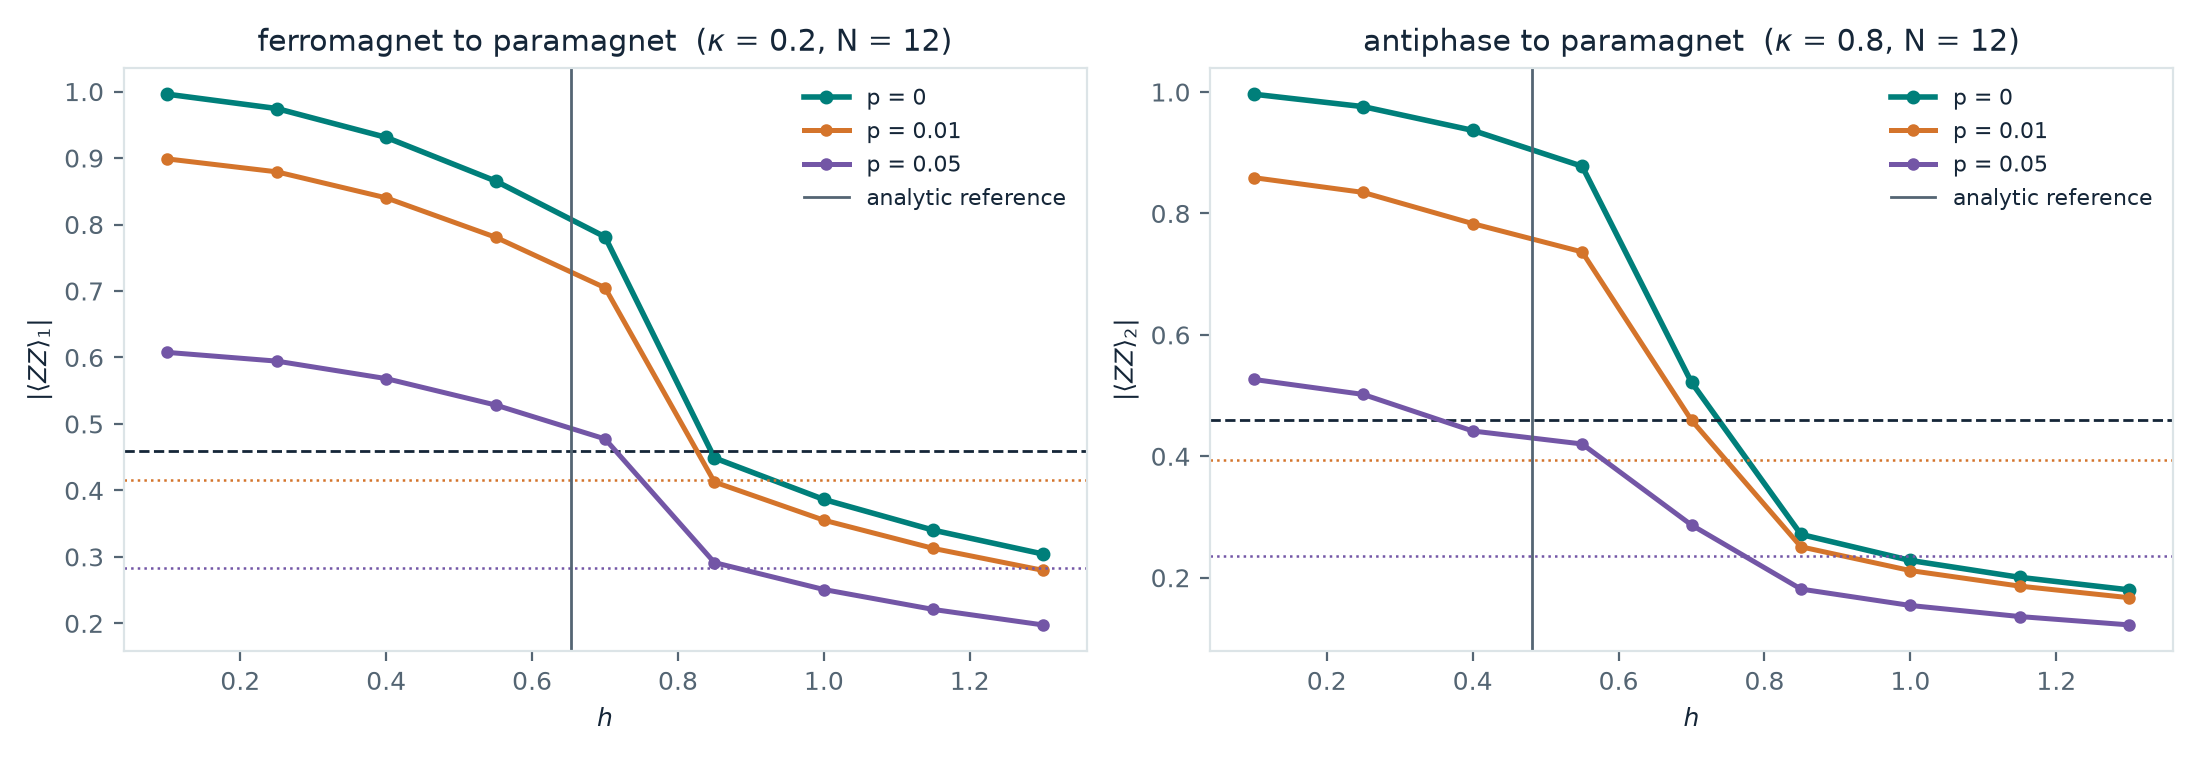

In [19]:
large=load('large_n_cut.json');large_analysis=load('large_n_cut_analysis.json')
assert all(len(rows)==9 for rows in large['cuts'].values())
assert large_analysis['points']==18
print('Preparation error:',large_analysis['preparation_energy_error'])
print(json.dumps(large_analysis['cuts'],indent=2))
show_figure('large_n_cut.png')


### What the rescaling test establishes
For each cut, fit a single attenuation factor α minimizing the squared difference between noisy and p=0 signal. Compare crossings of the fixed 0.46 threshold and the scaled α×0.46 threshold. Small residuals support approximate attenuation over the sampled cut. A missing fixed crossing means no sampled threshold crossing, not absence of a physical phase. Threshold fits and interpolation at Δh=0.15 cannot prove invariant transition locations.

In [20]:
for name,entry in large_analysis['cuts'].items():
    print(name,'p=0 threshold crossing:',entry['crossing_clean'])
    for p,row in entry['noise'].items():
        print(p,'attenuation',row['attenuation_factor'],'mean rescaling residual',row['mean_residual_after_rescaling'],
              'fixed shift',row['shift_fixed'],'rescaled shift',row['shift_rescaled'])


ferromagnet to paramagnet p=0 threshold crossing: 0.8449543583282638
p0.01 attenuation 0.9042489147612575 mean rescaling residual 0.0034944789540284843 fixed shift -0.019291401793776308 rescaled shift 0.0033107863760740708
p0.05 attenuation 0.614932640374513 mean rescaling residual 0.007969859639706664 fixed shift -0.13088867911933622 rescaled shift 0.03658974593494857
antiphase to paramagnet p=0 threshold crossing: 0.7369568562901079
p0.01 attenuation 0.8548963798423054 mean rescaling residual 0.012828636786983419 fixed shift -0.037321489864323265 rescaled shift 0.010591443268142986
p0.05 attenuation 0.5119411307492748 mean rescaling residual 0.02763016251918865 fixed shift -0.38262292910026197 rescaled shift 0.03595886966011452


## 11. The experiment as a game
The opening teaches Scan → Draw → Reveal with one clean map, one scan strength, and three clues before revealing. The full controls unlock after reveal, alongside an interactive clean/noisy/recalibrated comparison. Experienced players can skip ahead or replay the simple demo. Practice and Hunter have 90 and 60 energy; 20/100/500 shots cost 1/2/4 energy. The AI uses the same map and energy, with five-handle bisection rather than the study's reconstruction. Twelve famous GIFs and preserved personal recordings remain optional.

Game protocol: whole-register Z; each shot supplies both site-averaged correlators; joint categorical outcomes
Stages: [('clean8', 8, 0.0), ('noise01', 8, 0.01), ('noise05', 8, 0.05), ('short6', 6, 0.0), ('long12', 12, 0.0)]


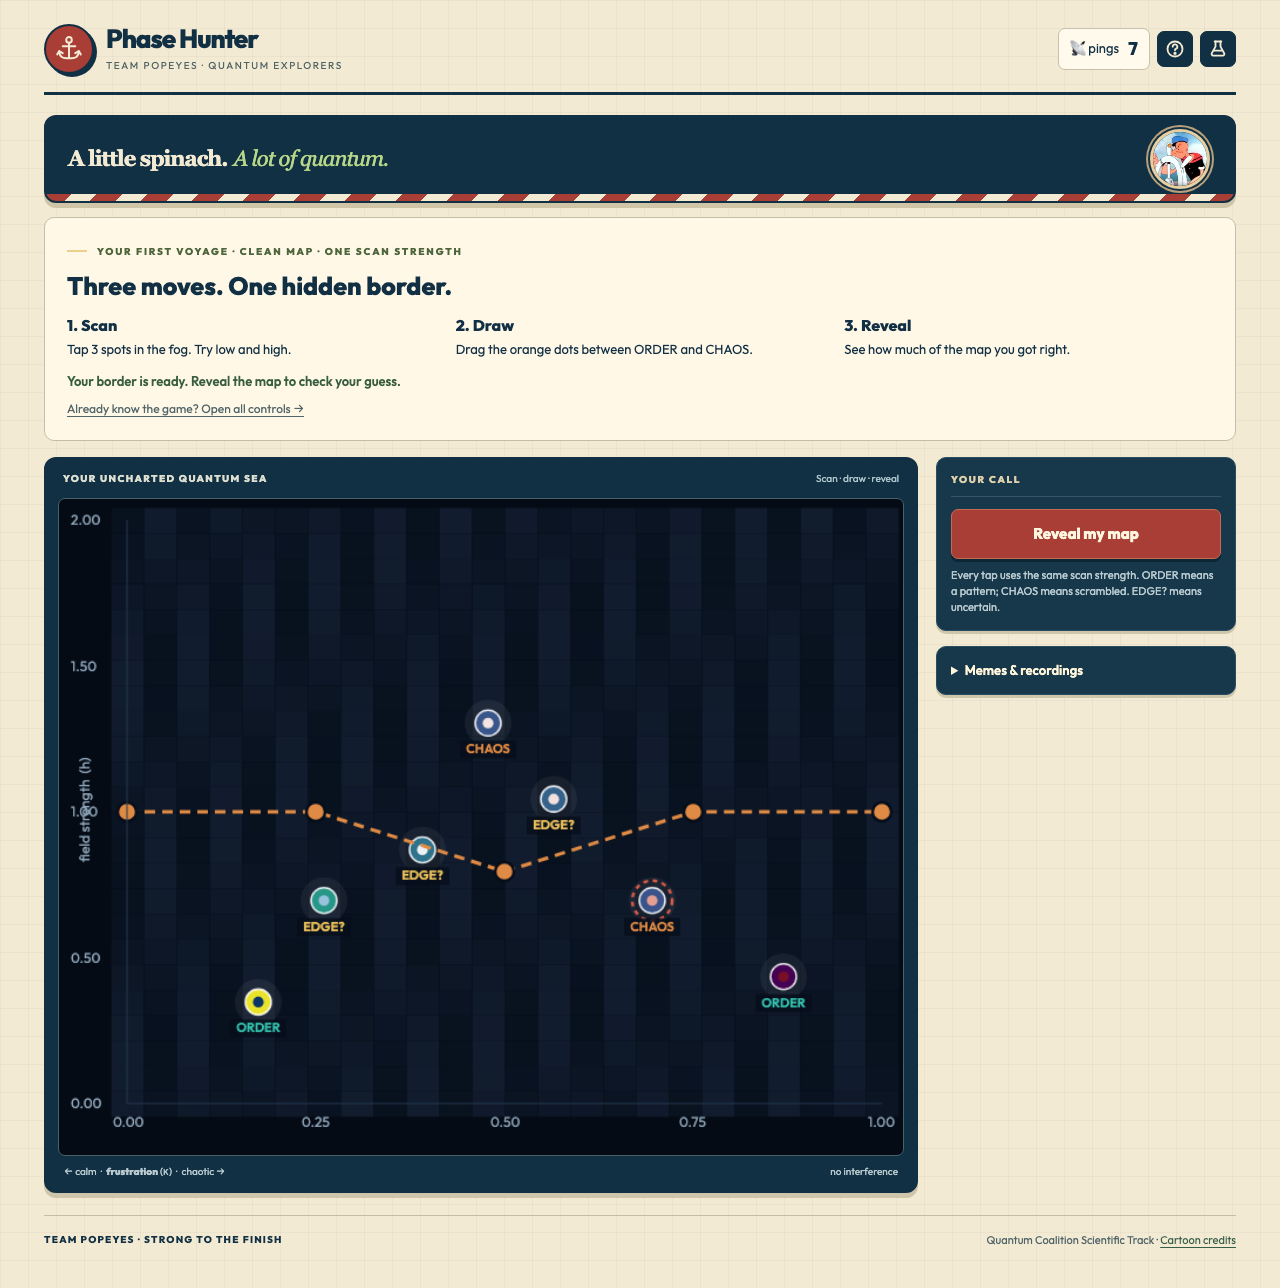

In [21]:
show_figure('gameplay.png')
data=json.loads((ROOT/'game/dataset.json').read_text())
print('Game protocol:',data['measurement_protocol'])
print('Stages:',[(s['id'],s['qubits'],s['p']) for s in data['stages']])


## 12. Reproduce and interpret responsibly
Run the commands in README.md. The saved scan, recovered readout, game distributions and figures are separate artifacts with explicit provenance. The reproducibility checks include Hamiltonian equality, full-register covariance, exact scan budgets, fixed-sector fidelity, parameter persistence, and game/AI controls.

Limitations: small finite rings; heuristic clustering/reconstruction; unresolved floating phase; imperfect VQE preparation; sparse N=12 cuts; no finite-shot extrapolation or hardware experiment. Team Popeyes is solo. The presentation video remains to be recorded.

Sources: [Scientific Track handout](https://github.com/benmcdonough20/QSITE-2026-QuantumCoalition/tree/main/Scientific%20Track), [PennyLane ANNNI tutorial](https://pennylane.ai/qml/demos/tutorial_annni), [qml.probs](https://docs.pennylane.ai/en/stable/code/api/pennylane.probs.html), [DepolarizingChannel](https://docs.pennylane.ai/en/stable/code/api/pennylane.DepolarizingChannel.html).